In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

# Cargar dataset real de Leonali
df = pd.read_parquet('../data/processed/dataset1_anonimizado.parquet')

print(f"Shape: {df.shape}")
print(f"\nColumnas: {df.columns.tolist()}")
print(f"\nTipos:\n{df.dtypes}")

Shape: (581306, 15)

Columnas: ['IdCliente', 'IdProducto', 'FechaProceso', 'Producto', 'Categoria1', 'Categoria2', 'marca', 'Canal1', 'Canal2', 'Costo_Entrega', 'Costo_Produccion', 'Costo_Venta', 'Piezas_Entregadas', 'Piezas_Ordenadas', 'Piezas_Producidas']

Tipos:
IdCliente                       str
IdProducto                      str
FechaProceso         datetime64[us]
Producto                        str
Categoria1                      str
Categoria2                      str
marca                           str
Canal1                          str
Canal2                          str
Costo_Entrega               float64
Costo_Produccion            float64
Costo_Venta                 float64
Piezas_Entregadas           float64
Piezas_Ordenadas            float64
Piezas_Producidas           float64
dtype: object


In [5]:
# ============================================================
# S4.5 — EXPLORACIÓN Y VARIABLES DERIVADAS
# ============================================================

# Variables numéricas base
numericas = ['Costo_Entrega', 'Costo_Produccion', 'Costo_Venta',
             'Piezas_Entregadas', 'Piezas_Ordenadas', 'Piezas_Producidas']

print("=== ESTADÍSTICAS BASE ===")
print(df[numericas].describe().round(2))

# --- VARIABLES DERIVADAS (más interesantes para negocio) ---
df['precio_unitario']    = df['Costo_Venta'] / df['Piezas_Entregadas'].replace(0, np.nan)
df['margen_unitario']    = (df['Costo_Venta'] - df['Costo_Produccion']) / df['Piezas_Entregadas'].replace(0, np.nan)
df['eficiencia_entrega'] = df['Piezas_Entregadas'] / df['Piezas_Ordenadas'].replace(0, np.nan)
df['costo_x_pieza']      = df['Costo_Produccion'] / df['Piezas_Producidas'].replace(0, np.nan)

print("\n=== VARIABLES DERIVADAS ===")
print(df[['precio_unitario','margen_unitario',
          'eficiencia_entrega','costo_x_pieza']].describe().round(2))

=== ESTADÍSTICAS BASE ===
       Costo_Entrega  Costo_Produccion  Costo_Venta  Piezas_Entregadas  \
count      581306.00         581306.00    581306.00          581306.00   
mean         5031.31           5128.73      5445.72             270.59   
std         12197.21          12325.67     13333.39             572.28   
min         -5644.38          -1813.48         0.00             -96.00   
25%           187.60            203.43       248.76              12.00   
50%          1133.95           1175.26      1249.43              64.00   
75%          4552.93           4665.00      4855.20             270.00   
max        716886.72         716886.72    716886.72           19008.00   

       Piezas_Ordenadas  Piezas_Producidas  
count         581306.00          581306.00  
mean             292.66             275.93  
std              632.55             578.73  
min                0.00            -117.00  
25%               13.00              12.00  
50%               72.00              

Registros después de filtrar outliers extremos: 483,634


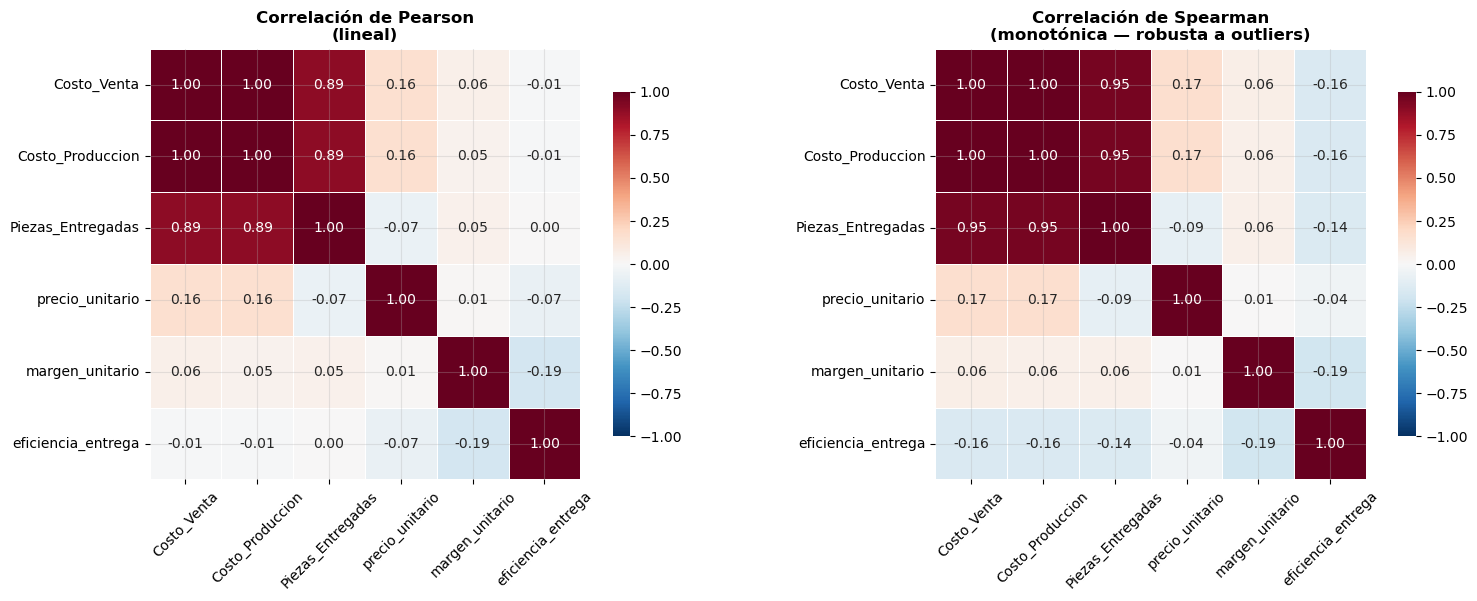


=== TOP CORRELACIONES (Pearson) ===
Costo_Venta        Piezas_Entregadas    0.893
Piezas_Entregadas  Costo_Venta          0.893
                   Costo_Produccion     0.893
Costo_Produccion   Piezas_Entregadas    0.893
                   precio_unitario      0.159
precio_unitario    Costo_Produccion     0.159
                   Costo_Venta          0.159
Costo_Venta        precio_unitario      0.159
margen_unitario    Costo_Venta          0.056
Costo_Venta        margen_unitario      0.056
dtype: float64


In [6]:
# ============================================================
# S4.5 — PEARSON Y SPEARMAN
# ============================================================

# Variables para análisis — base + derivadas
vars_analisis = ['Costo_Venta', 'Costo_Produccion', 'Piezas_Entregadas',
                 'precio_unitario', 'margen_unitario', 'eficiencia_entrega']

df_clean = df[vars_analisis].dropna()

# Limitar outliers extremos para visualización más limpia
# (no eliminamos — solo para el plot)
for col in vars_analisis:
    q99 = df_clean[col].quantile(0.99)
    q01 = df_clean[col].quantile(0.01)
    df_clean = df_clean[(df_clean[col] >= q01) & (df_clean[col] <= q99)]

print(f"Registros después de filtrar outliers extremos: {len(df_clean):,}")

# --- PEARSON ---
# Mide correlación LINEAL entre dos variables
# Supone distribución normal — sensible a outliers
corr_pearson = df_clean.corr(method='pearson')

# --- SPEARMAN ---
# Mide correlación MONOTÓNICA (no necesariamente lineal)
# Basada en rankings — robusta a outliers
# Mejor para distribuciones log-normales como las nuestras
corr_spearman = df_clean.corr(method='spearman')

# Visualizar ambas matrices
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, corr, titulo in zip(axes,
    [corr_pearson, corr_spearman],
    ['Correlación de Pearson\n(lineal)', 'Correlación de Spearman\n(monotónica — robusta a outliers)']):

    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                vmin=-1, vmax=1, center=0,
                ax=ax, square=True, linewidths=0.5,
                cbar_kws={'shrink': 0.8})
    ax.set_title(titulo, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../reports/S4.5_matriz_correlacion.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlaciones interesantes
print("\n=== TOP CORRELACIONES (Pearson) ===")
corr_pairs = corr_pearson.unstack()
corr_pairs = corr_pairs[corr_pairs < 0.999].sort_values(ascending=False)
print(corr_pairs.head(10).round(3))

=== CORRELACIONES CON P-VALUE ===
Par                                                 r      p-value   Significativa
-------------------------------------------------------------------------------------
Costo_Venta vs Piezas_Entregadas                0.893     0.00e+00            ✅ sí  ← Alta esperada
precio_unitario vs Piezas_Entregadas           -0.070     0.00e+00            ✅ sí  ← Hipótesis: precio vs volumen
eficiencia_entrega vs margen_unitario          -0.185     0.00e+00            ✅ sí  ← Correlación negativa interesante
Costo_Venta vs Costo_Produccion                 1.000     0.00e+00            ✅ sí  ← Correlación perfecta


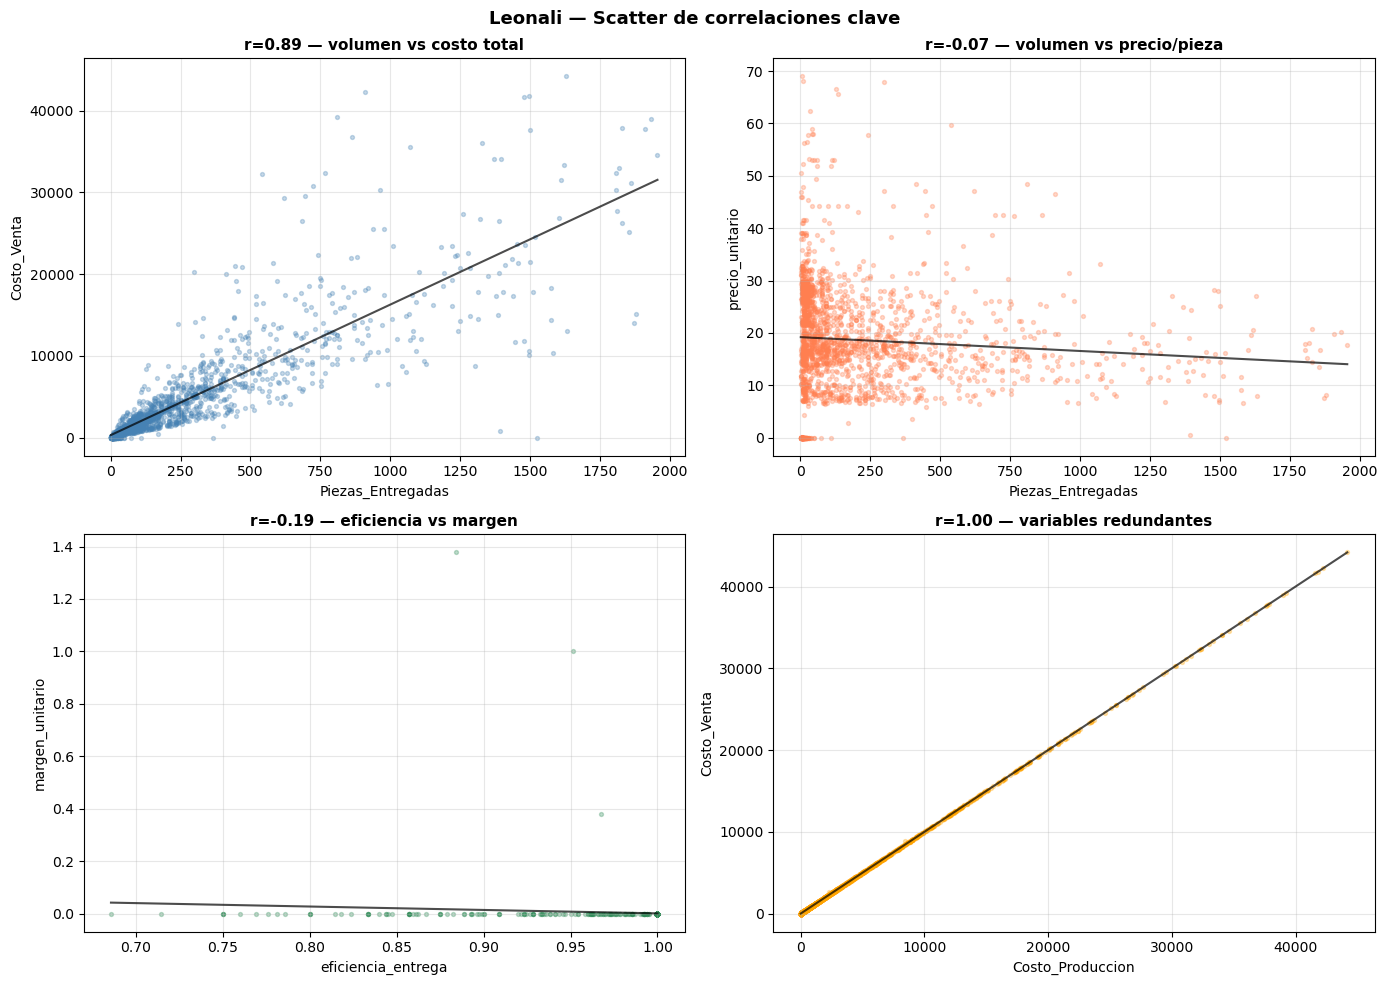

In [7]:
# ============================================================
# S4.5 — P-VALUE Y SCATTER DE CORRELACIONES CLAVE
# ============================================================

# P-value: ¿la correlación es estadísticamente significativa
# o podría ser por azar?
# Regla: p-value < 0.05 → correlación significativa

print("=== CORRELACIONES CON P-VALUE ===")
pares = [
    ('Costo_Venta',       'Piezas_Entregadas', 'Alta esperada'),
    ('precio_unitario',   'Piezas_Entregadas', 'Hipótesis: precio vs volumen'),
    ('eficiencia_entrega','margen_unitario',   'Correlación negativa interesante'),
    ('Costo_Venta',       'Costo_Produccion',  'Correlación perfecta'),
]

print(f"{'Par':<45} {'r':>7} {'p-value':>12}  {'Significativa':>14}")
print("-" * 85)
for v1, v2, desc in pares:
    r, p = stats.pearsonr(df_clean[v1], df_clean[v2])
    sig = "✅ sí" if p < 0.05 else "❌ no"
    print(f"{v1[:20]+' vs '+v2[:20]:<45} {r:>7.3f} {p:>12.2e}  {sig:>14}  ← {desc}")

# Scatter plots de las 4 correlaciones más informativas
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

configs = [
    ('Piezas_Entregadas', 'Costo_Venta',        'r=0.89 — volumen vs costo total',     'steelblue'),
    ('Piezas_Entregadas', 'precio_unitario',     'r=-0.07 — volumen vs precio/pieza',   'coral'),
    ('eficiencia_entrega','margen_unitario',     'r=-0.19 — eficiencia vs margen',      'seagreen'),
    ('Costo_Produccion',  'Costo_Venta',         'r=1.00 — variables redundantes',      'orange'),
]

# Muestra aleatoria para no sobrecargar el plot
sample = df_clean.sample(2000, random_state=42)

for ax, (x, y, titulo, color) in zip(axes.flatten(), configs):
    ax.scatter(sample[x], sample[y], alpha=0.3, s=8, color=color)
    # Línea de tendencia
    z = np.polyfit(sample[x], sample[y], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(sample[x].min(), sample[x].max(), 100)
    ax.plot(x_line, p_line(x_line), 'k-', linewidth=1.5, alpha=0.7)
    ax.set_xlabel(x, fontsize=10)
    ax.set_ylabel(y, fontsize=10)
    ax.set_title(titulo, fontsize=11, fontweight='bold')

plt.suptitle('Leonali — Scatter de correlaciones clave',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/S4.5_scatter_correlaciones.png', dpi=150, bbox_inches='tight')
plt.show()